In [94]:
#PHASE 1
#DATA LOADING AND DATA CLEANING
import pandas as pd
from matplotlib.ticker import FuncFormatter
import pandas as pd
import matplotlib.pyplot as plt

transactions =pd.read_csv(r"C:\@FILES\Projects\Aml Ibm\HI-Small_Trans.csv") #LOADING THE DATASET

In [95]:
transactions.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,"3,697.34",US Dollar,"3,697.34",US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,"14,675.57",US Dollar,"14,675.57",US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,"2,806.97",US Dollar,"2,806.97",US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,"36,682.97",US Dollar,"36,682.97",US Dollar,Reinvestment,0


In [96]:
transactions.info() #CHECKING DATA TYPES

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [97]:
transactions["Timestamp"]=pd.to_datetime(transactions["Timestamp"]) #CHANGING TIMESTAMP DATATYPE TO DATETIME
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           int64         
 2   Account             object        
 3   To Bank             int64         
 4   Account.1           object        
 5   Amount Received     float64       
 6   Receiving Currency  object        
 7   Amount Paid         float64       
 8   Payment Currency    object        
 9   Payment Format      object        
 10  Is Laundering       int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 426.2+ MB


In [98]:
transactions=transactions.rename(columns={"Account":"From Account","Account.1":"To Account"}) #CHANGING COLUMN NAMES ACCORDINGLY
transactions.head()

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,"3,697.34",US Dollar,"3,697.34",US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,"14,675.57",US Dollar,"14,675.57",US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,"2,806.97",US Dollar,"2,806.97",US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,"36,682.97",US Dollar,"36,682.97",US Dollar,Reinvestment,0


In [99]:
transactions.isna().sum() #CHECKING FOR MISSING VALUES

Timestamp             0
From Bank             0
From Account          0
To Bank               0
To Account            0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [100]:
transactions.duplicated().sum()

np.int64(9)

In [101]:
transactions[transactions.duplicated(keep=False)] #FINDING DUPLICATES 


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
863293,2022-09-01 16:20:00,12004,800C927C1,12004,800C927C0,0.00,Bitcoin,0.08,Euro,ACH,0
863294,2022-09-01 16:20:00,12004,800C927C1,220,813D8C1E1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0
863295,2022-09-01 16:20:00,12004,800C927C1,12004,800C927C0,0.00,Bitcoin,0.08,Euro,ACH,0
863296,2022-09-01 16:20:00,12004,800C927C1,220,813D8C1E1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0
3684003,2022-09-07 21:25:00,29992,8099A29B1,220,813725AE1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0
3684005,2022-09-07 21:25:00,29992,8099A29B1,220,813725AE1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0
4166784,2022-09-08 21:05:00,113779,811144AB1,113779,811144AB0,0.00,Bitcoin,0.02,US Dollar,ACH,0
4166785,2022-09-08 21:05:00,113779,811144AB1,53744,813C777F1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0
4166786,2022-09-08 21:05:00,113779,811144AB1,113779,811144AB0,0.00,Bitcoin,0.02,US Dollar,ACH,0
4166787,2022-09-08 21:05:00,113779,811144AB1,53744,813C777F1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0


In [102]:
transactions = transactions.drop_duplicates() #DELETING DUPLICATES

In [103]:
transactions.duplicated().sum() #VERIFYING THE DUPLICATES

np.int64(0)

In [104]:
transactions["Is Laundering"].value_counts() #DATA VALIDATION

Is Laundering
0    5073159
1       5177
Name: count, dtype: int64

In [105]:
#DATA VALIDATION
display(transactions["Payment Currency"].value_counts())

display(transactions["Receiving Currency"].value_counts())

display(transactions["Payment Format"].value_counts())

Payment Currency
US Dollar            1895169
Euro                 1168296
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146061
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            70703
Name: count, dtype: int64

Receiving Currency
US Dollar            1879341
Euro                 1172017
Swiss Franc           237884
Yuan                  206551
Shekel                194988
Rupee                 192065
UK Pound              181255
Ruble                 157361
Yen                   156319
Bitcoin               148142
Canadian Dollar       141357
Australian Dollar     138511
Mexican Peso          111030
Saudi Riyal            89971
Brazil Real            71544
Name: count, dtype: int64

Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600793
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146086
Name: count, dtype: int64

In [106]:
#DATA VALIDATION
display(transactions["Timestamp"].min())
display(transactions["Timestamp"].max())

print("From Bank data validation")
display(transactions["From Bank"].min())
display(transactions["From Bank"].max())
display(transactions["From Bank"].nunique())

print("To Bank data validation")
display(transactions["To Bank"].min())
display(transactions["To Bank"].max())
display(transactions["To Bank"].nunique())

print("From Account data validation")
display(transactions["From Account"].min())
display(transactions["From Account"].max())
display(transactions["From Account"].nunique())

print("To Account data validation")
display(transactions["To Account"].min())
display(transactions["To Account"].max())
display(transactions["To Account"].nunique())

print("Amount received data validation")
display(transactions["Amount Received"].min())
display(transactions["Amount Received"].max())
display(transactions["Amount Received"].nunique())

print("Amount Paid data validation")
display(transactions["Amount Paid"].min())
display(transactions["Amount Paid"].max())
display(transactions["Amount Paid"].nunique())

Timestamp('2022-09-01 00:00:00')

Timestamp('2022-09-18 16:18:00')

From Bank data validation


np.int64(1)

np.int64(356303)

...

915161

Amount Paid data validation


np.float64(1e-06)

np.float64(1046302363293.48)

923873

In [107]:
transactions.max() #DATA VALIDATION

Timestamp             2022-09-18 16:18:00
From Bank                          356303
From Account                    814965B51
To Bank                            356294
To Account                      814965B51
Amount Received      1,046,302,363,293.48
Receiving Currency                   Yuan
Amount Paid          1,046,302,363,293.48
Payment Currency                     Yuan
Payment Format                       Wire
Is Laundering                           1
dtype: object

In [108]:
transactions.min()   #DATA VALIDATION


Timestamp             2022-09-01 00:00:00
From Bank                               1
From Account                    100428660
To Bank                                 1
To Account                      100428660
Amount Received                      0.00
Receiving Currency      Australian Dollar
Amount Paid                          0.00
Payment Currency        Australian Dollar
Payment Format                        ACH
Is Laundering                           0
dtype: object

In [109]:
#EDA
#PHASE 2

transactions["Payment Format"].value_counts() #payment format 

Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600793
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146086
Name: count, dtype: int64

In [110]:
transactions["Payment Format"].value_counts(normalize=True) *100 #percentage of payment format count

Payment Format
Cheque         36.71
Credit Card    26.06
ACH            11.83
Cash            9.67
Reinvestment    9.47
Wire            3.38
Bitcoin         2.88
Name: proportion, dtype: float64

In [111]:

pd.set_option("display.float_format","{:,.2f}".format) #changing output result from numerical to 2 decimal 
transactions["Amount Paid"].describe()

count           5,078,336.00
mean            4,509,281.36
std           869,773,601.62
min                     0.00
25%                   184.48
50%                 1,414.57
75%                12,298.15
max     1,046,302,363,293.48
Name: Amount Paid, dtype: float64

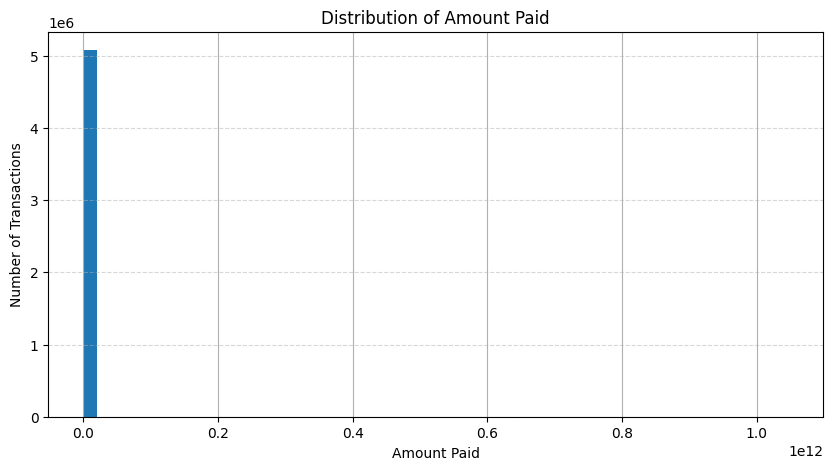

In [112]:


plt.figure(figsize=(10, 5))

transactions["Amount Paid"].hist(bins=50)

plt.title("Distribution of Amount Paid")
plt.xlabel("Amount Paid")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [113]:
transactions["Amount Paid"].skew()

np.float64(858.7470221420566)

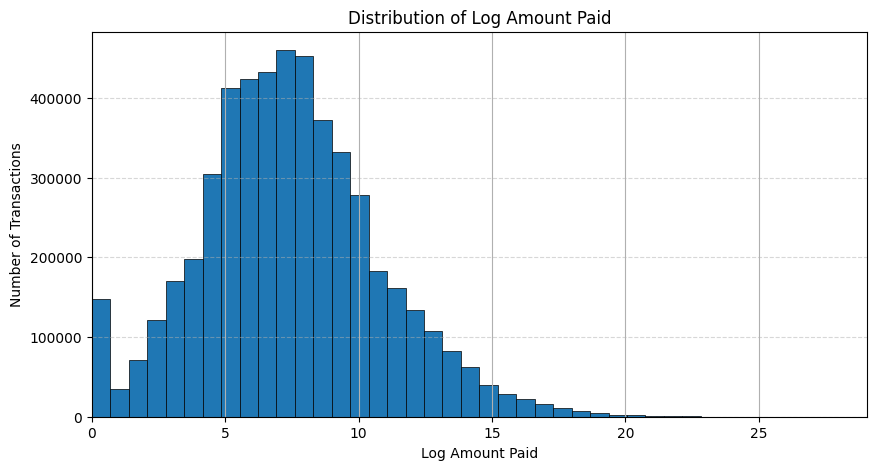

In [122]:
import numpy as np
transactions["Log Amount Paid"] = np.log1p(transactions["Amount Paid"])

plt.figure(figsize=(10, 5))

transactions["Log Amount Paid"].hist(bins=40,edgecolor="black",linewidth=0.5)

plt.title("Distribution of Log Amount Paid")
plt.xlabel("Log Amount Paid")
plt.ylabel("Number of Transactions")
plt.xlim(0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [123]:

pd.set_option("display.float_format","{:,.2f}".format) #changing output result from numerical to 2 decimal 
transactions["Amount Received"].describe()

count           5,078,336.00
mean            5,988,736.68
std         1,037,184,027.93
min                     0.00
25%                   183.37
50%                 1,411.04
75%                12,346.30
max     1,046,302,363,293.48
Name: Amount Received, dtype: float64

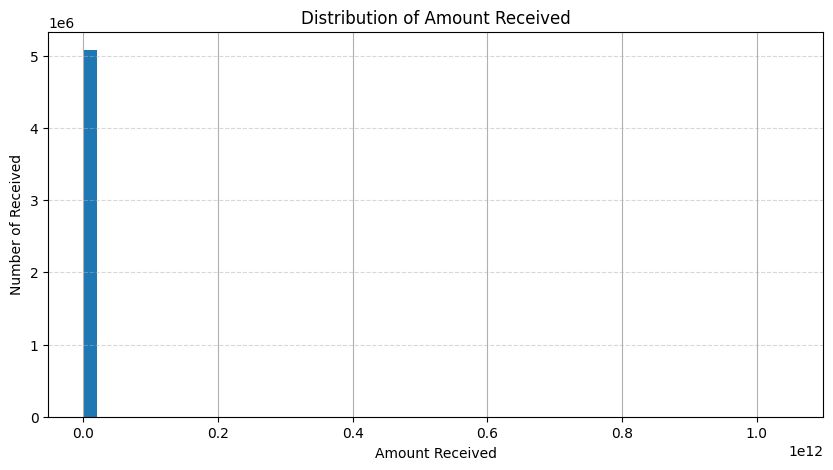

In [124]:


plt.figure(figsize=(10, 5))

transactions["Amount Received"].hist(bins=50)

plt.title("Distribution of Amount Received")
plt.xlabel("Amount Received")
plt.ylabel("Number of Received")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [125]:
transactions["Amount Received"].skew()

np.float64(649.3383419053324)

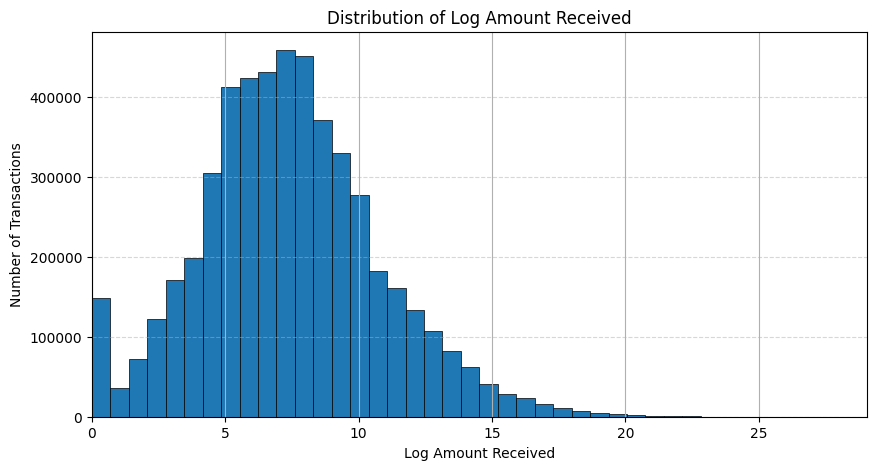

In [126]:

transactions["Log Amount Received"] = np.log1p(transactions["Amount Received"])

plt.figure(figsize=(10, 5))

transactions["Log Amount Received"].hist(bins=40,edgecolor="black",linewidth=0.5)

plt.title("Distribution of Log Amount Received")
plt.xlabel("Log Amount Received")
plt.ylabel("Number of Transactions")
plt.xlim(0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [127]:
transactions["Log Amount Paid"].skew()

np.float64(0.34567959040043944)

In [128]:
transactions["Log Amount Received"].skew()

np.float64(0.3623659073764102)

In [135]:
transactions["Payment Format"].value_counts()

Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600793
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146086
Name: count, dtype: int64

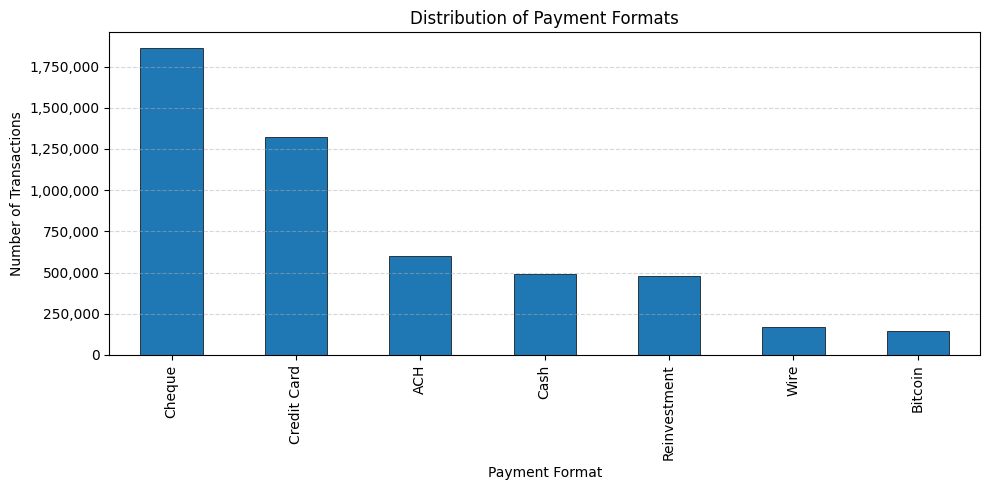

In [142]:


plt.figure(figsize=(10, 5))

transactions["Payment Format"].value_counts().plot(
    kind="bar",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Distribution of Payment Formats")
plt.xlabel("Payment Format")
plt.ylabel("Number of Transactions")
plt.ticklabel_format(style="plain", axis="y")


plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
) #this bit is copied from chatgpt
# Format y-axis labels with commas for better readability


plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [140]:
transactions["Payment Currency"].value_counts(normalize=True)*100

Payment Currency
US Dollar           37.32
Euro                23.01
Swiss Franc          4.62
Yuan                 4.21
Shekel               3.78
Rupee                3.75
UK Pound             3.56
Yen                  3.06
Ruble                3.06
Bitcoin              2.88
Canadian Dollar      2.76
Australian Dollar    2.69
Mexican Peso         2.17
Saudi Riyal          1.75
Brazil Real          1.39
Name: proportion, dtype: float64

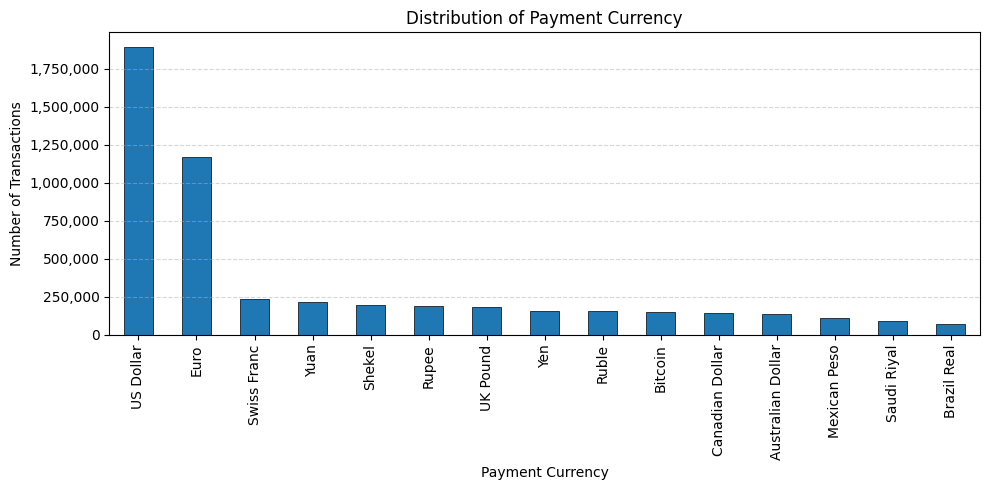

In [143]:

plt.figure(figsize=(10, 5))

transactions["Payment Currency"].value_counts().plot(
    kind="bar",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Distribution of Payment Currency")
plt.xlabel("Payment Currency")
plt.ylabel("Number of Transactions")
plt.ticklabel_format(style="plain", axis="y")


plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
) #this bit is copied from chatgpt
# Format y-axis labels with commas for better readability


plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [144]:
transactions["Receiving Currency"].value_counts(normalize=True) * 100

Receiving Currency
US Dollar           37.01
Euro                23.08
Swiss Franc          4.68
Yuan                 4.07
Shekel               3.84
Rupee                3.78
UK Pound             3.57
Ruble                3.10
Yen                  3.08
Bitcoin              2.92
Canadian Dollar      2.78
Australian Dollar    2.73
Mexican Peso         2.19
Saudi Riyal          1.77
Brazil Real          1.41
Name: proportion, dtype: float64

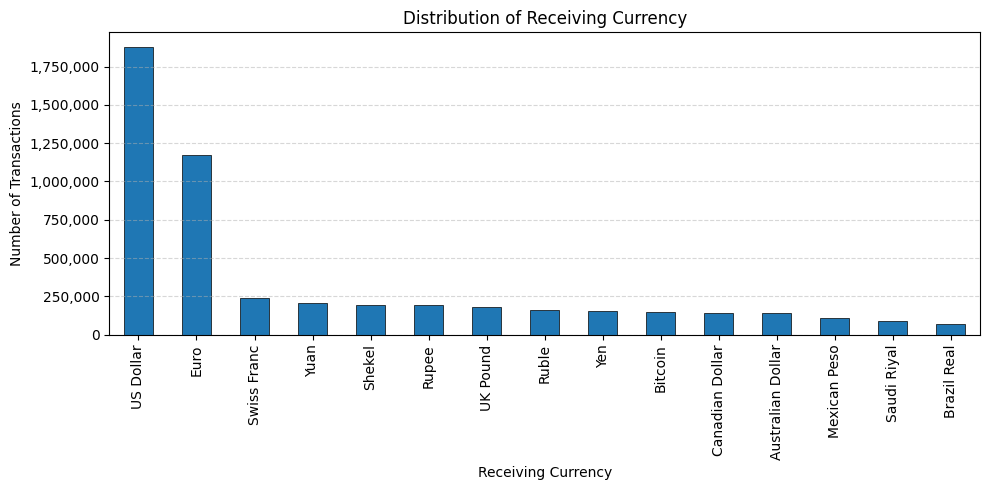

In [145]:

plt.figure(figsize=(10, 5))

transactions["Receiving Currency"].value_counts().plot(
    kind="bar",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Distribution of Receiving Currency")
plt.xlabel("Receiving Currency")
plt.ylabel("Number of Transactions")
plt.ticklabel_format(style="plain", axis="y")


plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
) #this bit is copied from chatgpt
# Format y-axis labels with commas for better readability


plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [149]:
transactions["Hour"] = transactions["Timestamp"].dt.hour

transactions["Hour"].value_counts().sort_index()


Hour
0     634726
1     193728
2     193143
3     193249
4     193166
5     193900
6     194456
7     193336
8     192921
9     192952
10    193227
11    193500
12    192972
13    192521
14    192787
15    194871
16    193405
17    193154
18    193321
19    192824
20    192809
21    192187
22    191836
23    193345
Name: count, dtype: int64

In [150]:
transactions.loc[
    transactions["Hour"] == 0,
    "Timestamp"
].head(20)

0    2022-09-01 00:20:00
1    2022-09-01 00:20:00
2    2022-09-01 00:00:00
3    2022-09-01 00:02:00
4    2022-09-01 00:06:00
5    2022-09-01 00:03:00
6    2022-09-01 00:08:00
7    2022-09-01 00:16:00
8    2022-09-01 00:26:00
9    2022-09-01 00:21:00
10   2022-09-01 00:04:00
11   2022-09-01 00:04:00
12   2022-09-01 00:08:00
13   2022-09-01 00:17:00
14   2022-09-01 00:11:00
15   2022-09-01 00:09:00
16   2022-09-01 00:11:00
17   2022-09-01 00:00:00
18   2022-09-01 00:28:00
19   2022-09-01 00:22:00
Name: Timestamp, dtype: datetime64[ns]

In [151]:
(transactions["Timestamp"].dt.time == pd.to_datetime("00:00:00").time()).sum()

np.int64(18034)

In [155]:
transactions["Timestamp"].dt.hour.head()

0    0
1    0
2    0
3    0
4    0
Name: Timestamp, dtype: int32

In [152]:
transactions.groupby(transactions["Timestamp"].dt.date)["Hour"].value_counts().unstack(fill_value=0)

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-09-01,344208,33138,33917,33505,33316,33273,33949,33774,33065,32806,...,33199,33849,33277,33217,33792,33587,33385,33310,33615,34069
2022-09-02,45400,30929,30967,31010,30442,31372,31274,31077,30521,30610,...,30738,31499,30531,30947,30381,30668,31049,30735,30710,30545
2022-09-03,22372,8022,7645,7896,8177,8073,8112,8021,8014,7870,...,7804,8074,8105,8041,8053,8152,8199,8140,8061,8224
2022-09-04,22732,7988,8080,8154,8150,7939,8051,7742,7853,8211,...,8220,8095,8102,8106,7958,8032,8157,8127,7988,7903
2022-09-05,34352,19453,19732,19495,19451,19651,19504,19391,19854,19706,...,19429,19508,19592,19287,19207,19243,19643,19228,19262,19881
2022-09-06,33750,19784,19438,19711,19735,19380,19362,19657,19118,19401,...,19431,19436,19715,19102,19663,19778,19339,19347,19200,19308
2022-09-07,34055,19899,19154,19427,19333,19730,19982,19523,19455,19311,...,19969,19669,19808,19671,19660,19062,19221,19566,19157,19520
2022-09-08,33964,19358,19367,19600,19511,19403,19199,19394,19730,19728,...,19357,19976,19494,19703,19450,19710,19523,19227,19344,19441
2022-09-09,41280,26859,26621,26351,26582,26893,26878,26514,26996,27258,...,26784,26560,26672,27209,27015,26657,26109,26193,26444,26747


In [156]:
transactions["Timestamp"].dt.date.value_counts().sort_index()

Timestamp
2022-09-01    1114919
2022-09-02     754449
2022-09-03     207382
2022-09-04     207430
2022-09-05     482650
2022-09-06     482089
2022-09-07     482750
2022-09-08     482771
2022-09-09     654463
2022-09-10     208325
2022-09-11        396
2022-09-12        281
2022-09-13        184
2022-09-14        121
2022-09-15         46
2022-09-16         46
2022-09-17         23
2022-09-18         11
Name: count, dtype: int64